# Урок 2. PyTorch: тензоры, модули, цикл обучения

🎯 **Цели урока**

- освоить тензоры, устройства и autograd в PyTorch;
- описать модель через `nn.Module` и данные через `DataLoader`;
- написать цикл обучения и оценки, обучить MLP и CNN на Fashion-MNIST;
- измерить, когда GPU Apple (MPS) быстрее CPU, а когда нет;
- сохранить и загрузить модель.

📖 **Теория:** разделы «Как обучать глубокие сети» и «PyTorch».

**Данные:** Fashion-MNIST (Zalando, лицензия MIT) — 70 тысяч картинок одежды 28×28 в 10 классах.
Скачивается при первом запуске (30 МБ). Урок запускайте нативно (`make native M=03`): в Docker нет MPS.

In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.metrics import confusion_matrix
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets

from mlcourse import data_dir, get_device, seed_everything

seed_everything(0)
device = get_device()
print("PyTorch", torch.__version__, "| устройство:", device)

PyTorch 2.14.0 | устройство: mps


## 1. Тензоры

Тензор — это массив NumPy плюс устройство, тип и autograd.

In [2]:
a = torch.tensor([[1.0, 2.0, 3.0], [4.0, 5.0, 6.0]])
print(a.shape, a.dtype, a.device)
print("broadcasting:", (a - a.mean(dim=0)).tolist())
print("матричное умножение:", (a @ a.T).tolist())

x_np = np.linspace(0, 1, 3)
x_t = torch.from_numpy(x_np)
print("из NumPy:", x_t.dtype, "— NumPy по умолчанию даёт float64")

torch.Size([2, 3]) torch.float32 cpu
broadcasting: [[-1.5, -1.5, -1.5], [1.5, 1.5, 1.5]]
матричное умножение: [[14.0, 32.0], [32.0, 77.0]]
из NumPy: torch.float64 — NumPy по умолчанию даёт float64


Перенос на устройство — `.to(device)`. На MPS нет float64, поэтому тензоры из NumPy приводим к float32.

In [3]:
if device.type == "mps":
    try:
        x_t.to(device)
    except (TypeError, RuntimeError) as e:
        print("float64 на MPS:", str(e).split(".")[0])
print("float32 на устройстве:", x_t.float().to(device))

float64 на MPS: Cannot convert a MPS Tensor to float64 dtype as the MPS framework doesn't support float64
float32 на устройстве: 

tensor([0.0000, 0.5000, 1.0000], device='mps:0')


## 2. Autograd на тензорах

То же, что наш `Value` из урока 1, но для целых массивов. $y = \sum x_i^2$, значит $\partial y/\partial x = 2x$.

In [4]:
x = torch.tensor([1.0, -2.0, 3.0], requires_grad=True)
y = (x**2).sum()
y.backward()
print("градиент:", x.grad)

with torch.no_grad():  # внутри блока граф не строится: так делают при оценке модели
    z = x * 2
print("requires_grad внутри no_grad:", z.requires_grad)

градиент: tensor([ 2., -4.,  6.])
requires_grad внутри no_grad: False


## 3. Данные

Загрузим Fashion-MNIST, превратим в тензоры и нормируем по статистике **обучающей** выборки.

55000 5000 10000


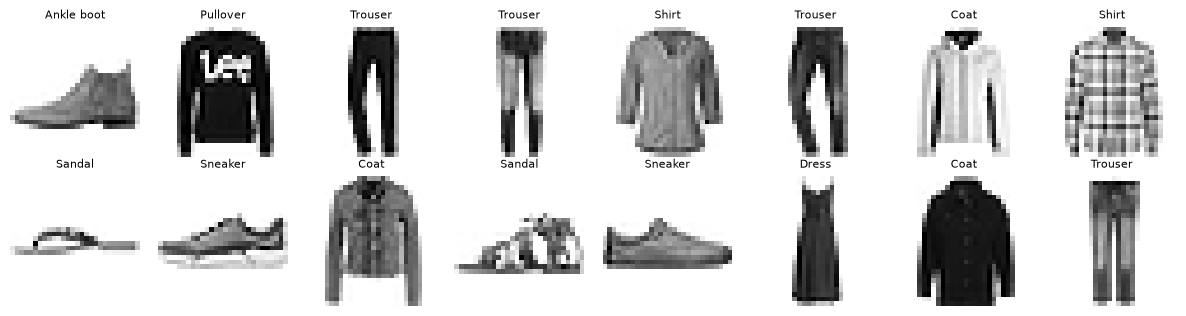

In [5]:
train_raw = datasets.FashionMNIST(data_dir("fashion-mnist"), train=True, download=True)
test_raw = datasets.FashionMNIST(data_dir("fashion-mnist"), train=False, download=True)
classes = train_raw.classes

X_all = train_raw.data.float().unsqueeze(1) / 255  # [60000, 1, 28, 28]
y_all = train_raw.targets
X_test = test_raw.data.float().unsqueeze(1) / 255
y_test = test_raw.targets

mean, std = X_all.mean(), X_all.std()
X_all, X_test = (X_all - mean) / std, (X_test - mean) / std

perm = torch.randperm(len(X_all))
val_idx, train_idx = perm[:5000], perm[5000:]
train_ds = TensorDataset(X_all[train_idx], y_all[train_idx])
val_ds = TensorDataset(X_all[val_idx], y_all[val_idx])
test_ds = TensorDataset(X_test, y_test)
print(len(train_ds), len(val_ds), len(test_ds))

fig, axes = plt.subplots(2, 8, figsize=(12, 3.2))
for ax, i in zip(axes.ravel(), range(16)):
    ax.imshow(test_raw.data[i], cmap="gray_r")
    ax.set_title(classes[test_raw.targets[i]], fontsize=8)
    ax.axis("off")
plt.tight_layout()
plt.show()

## 4. Модели

`nn.Module` регистрирует параметры всех вложенных слоёв. Сравним MLP и маленькую CNN.

In [6]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),                      # [B, 1, 28, 28] → [B, 784]
            nn.Linear(784, 256), nn.ReLU(),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, 10),                # логиты 10 классов
        )

    def forward(self, x):
        return self.net(x)


class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),   # → [B, 32, 14, 14]
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),  # → [B, 64, 7, 7]
        )
        self.head = nn.Sequential(nn.Flatten(), nn.Linear(64 * 7 * 7, 128), nn.ReLU(), nn.Dropout(0.3),
                                  nn.Linear(128, 10))

    def forward(self, x):
        return self.head(self.features(x))


def n_params(model):
    return sum(p.numel() for p in model.parameters())


print(f"MLP: {n_params(MLP()):,} параметров".replace(",", " "))
print(f"CNN: {n_params(CNN()):,} параметров".replace(",", " "))
print([name for name, _ in CNN().named_parameters()][:4], "…")

MLP: 235 146 параметров
CNN: 421 642 параметров
['features.0.weight', 'features.0.bias', 'features.3.weight', 'features.3.bias'] …


## 5. Цикл обучения

In [7]:
def train_epoch(model, loader, optimizer, device):
    model.train()
    total, n = 0.0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = nn.functional.cross_entropy(model(xb), yb)  # логиты, не softmax!
        loss.backward()
        optimizer.step()
        total += loss.item() * len(xb)
        n += len(xb)
    return total / n


@torch.no_grad()
def predict(model, loader, device):
    model.eval()
    return torch.cat([model(xb.to(device)).argmax(dim=1).cpu() for xb, _ in loader])


def accuracy(model, ds, device):
    loader = DataLoader(ds, batch_size=1024)
    return (predict(model, loader, device) == ds.tensors[1]).float().mean().item()


def fit(model, epochs, device, lr=1e-3):
    model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    loader = DataLoader(train_ds, batch_size=128, shuffle=True)
    history = []
    for epoch in range(epochs):
        start = time.perf_counter()
        loss = train_epoch(model, loader, optimizer, device)
        history.append((loss, accuracy(model, val_ds, device)))
        print(f"эпоха {epoch + 1}: loss {loss:.4f}, val accuracy {history[-1][1]:.4f}, "
              f"{time.perf_counter() - start:.1f} с")
    return history


seed_everything(0)
mlp = MLP()
mlp_history = fit(mlp, epochs=5, device="cpu")

эпоха 1: loss 0.4922, val accuracy 0.8572, 0.6 с


эпоха 2: loss 0.3543, val accuracy 0.8672, 0.7 с


эпоха 3: loss 0.3140, val accuracy 0.8832, 0.8 с


эпоха 4: loss 0.2893, val accuracy 0.8764, 0.7 с


эпоха 5: loss 0.2704, val accuracy 0.8770, 0.7 с


MLP обучали на CPU — почему, увидим в разделе 7. CNN обучим на лучшем доступном устройстве.

эпоха 1: loss 0.5109, val accuracy 0.8654, 7.6 с


эпоха 2: loss 0.3227, val accuracy 0.8938, 7.3 с


эпоха 3: loss 0.2760, val accuracy 0.8932, 7.3 с


эпоха 4: loss 0.2431, val accuracy 0.9010, 7.4 с


эпоха 5: loss 0.2200, val accuracy 0.9140, 7.3 с


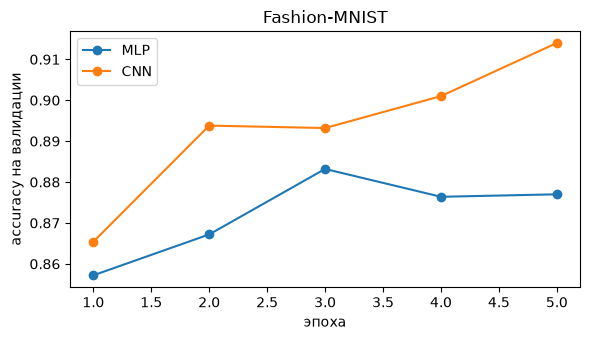

In [8]:
seed_everything(0)
cnn = CNN()
cnn_history = fit(cnn, epochs=5, device=device)

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(range(1, 6), [h[1] for h in mlp_history], marker="o", label="MLP")
ax.plot(range(1, 6), [h[1] for h in cnn_history], marker="o", label="CNN")
ax.set(xlabel="эпоха", ylabel="accuracy на валидации", title="Fashion-MNIST")
ax.legend()
plt.tight_layout()
plt.show()

CNN точнее MLP на три-четыре процентных пункта. Параметров у неё почти вдвое больше, но 95% из них —
в полносвязной «голове» (3136 × 128). Свёрточная часть, которая и даёт выигрыш, — всего 19 тысяч
параметров: свёртки знают, что соседние пиксели связаны, и ищут одни и те же признаки по всей картинке.

## 6. Ошибки модели

Тестовую выборку открываем один раз, для финальной модели.

CNN на тесте: accuracy 0.9084


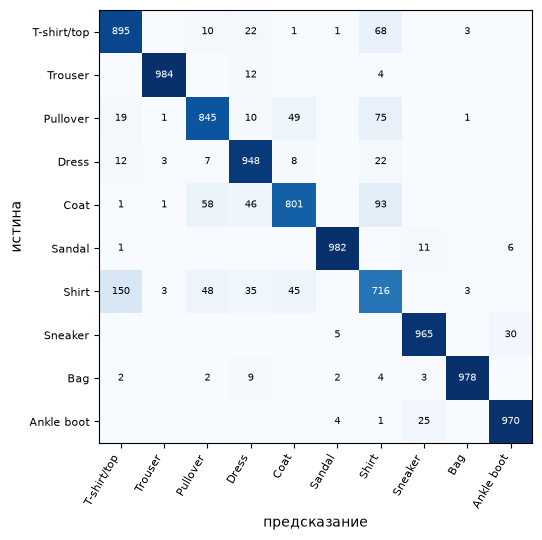

In [9]:
test_pred = predict(cnn, DataLoader(test_ds, batch_size=1024), device)
print(f"CNN на тесте: accuracy {(test_pred == y_test).float().mean():.4f}")

cm = confusion_matrix(y_test, test_pred)
fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(10), classes, rotation=60, ha="right", fontsize=8)
ax.set_yticks(range(10), classes, fontsize=8)
for (i, j), v in np.ndenumerate(cm):
    if v:
        ax.text(j, i, v, ha="center", va="center", fontsize=7, color="w" if v > 500 else "k")
ax.set(xlabel="предсказание", ylabel="истина")
plt.tight_layout()
plt.show()

Хуже всего модель узнаёт рубашки (`Shirt`): их путают с футболками, пальто и пуловерами. Обувь и сумки
почти не путаются ни с чем. На картинках 28×28 рубашку от футболки не всегда отличит и человек. Посмотрим на ошибки:

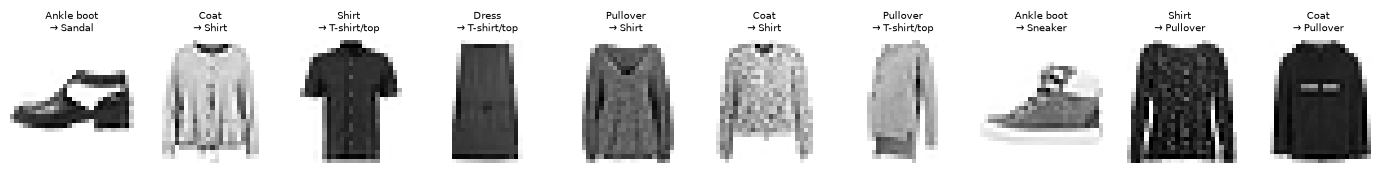

In [10]:
wrong = torch.nonzero(test_pred != y_test).squeeze(1)[:10]
fig, axes = plt.subplots(1, 10, figsize=(14, 2))
for ax, i in zip(axes, wrong):
    ax.imshow(test_raw.data[i], cmap="gray_r")
    ax.set_title(f"{classes[y_test[i]]}\n→ {classes[test_pred[i]]}", fontsize=7)
    ax.axis("off")
plt.tight_layout()
plt.show()

## 7. 📏 MPS или CPU?

Замерим одну эпоху каждой модели на каждом доступном устройстве. На Mac будут CPU и MPS,
на машине с NVIDIA — CPU и CUDA.

In [11]:
def epoch_seconds(make_model, dev):
    seed_everything(0)
    model = make_model().to(dev)
    optimizer = torch.optim.AdamW(model.parameters())
    loader = DataLoader(train_ds, batch_size=128, shuffle=True)
    train_epoch(model, DataLoader(val_ds, batch_size=128), optimizer, dev)  # прогрев: компиляция ядер
    start = time.perf_counter()
    train_epoch(model, loader, optimizer, dev)
    if dev.type == "mps":
        torch.mps.synchronize()
    return time.perf_counter() - start


devices = [torch.device("cpu")] + ([device] if device.type != "cpu" else [])
for name, make in [("MLP", MLP), ("CNN", CNN)]:
    times = {d.type: epoch_seconds(make, d) for d in devices}
    print(f"{name}: " + ", ".join(f"{k} {v:.1f} с" for k, v in times.items()))

MLP: cpu 0.7 с, mps 1.5 с


CNN: cpu 16.8 с, mps 7.1 с


Маленький MLP быстрее на CPU. На каждом батче GPU нужно запустить десяток крошечных ядер, и накладные
расходы на запуск больше самих вычислений. У CNN вычислений на порядок больше, и GPU выигрывает.
Вывод: устройство выбирают замером, а не по привычке. Для трансформеров в M06 и M07 выигрыш GPU
будет огромным.

## 8. Сохранение и загрузка

In [12]:
path = data_dir("checkpoints") / "fashion_cnn.pt"
torch.save(cnn.state_dict(), path)
print("размер файла:", round(path.stat().st_size / 1e6, 2), "МБ")

restored = CNN()
restored.load_state_dict(torch.load(path, weights_only=True))  # weights_only: без исполнения кода
same = torch.equal(predict(restored, DataLoader(test_ds, batch_size=1024), "cpu"), test_pred)
print("предсказания совпадают:", same)

размер файла: 1.69 МБ


предсказания совпадают: True


`state_dict` — просто словарь «имя параметра → тензор». Класс модели нужно иметь в коде: файл хранит
веса, а не архитектуру.

## ✅ Итоги

- Тензор = массив + устройство + dtype + autograd. На MPS — только float32 и ниже.
- Цикл обучения: `zero_grad` → прямой проход → `backward` → `step`. Оценка — в `eval()` и `no_grad()`.
- Свёртки дают лучшую точность при меньшем числе параметров, чем MLP.
- GPU выгоден, когда вычислений много. Маленькие модели бывают быстрее на CPU.
- Сохраняют `state_dict` и загружают с `weights_only=True`.

✍️ **Упражнения:** `exercises/ex02_training.py` (цикл обучения) и `exercises/ex03_conv.py` (свёртка с нуля).